# Task 3: Cognitive load and the data-ink ratio
Data: `car_crashes.csv` (51 rows: 50 states + DC, none excluded) and `tips.csv` (244 rows, none excluded).
Only `total` is plotted. `total` is drivers in fatal crashes per billion miles; `speeding`/`alcohol`/... are percentages and `ins_*` are dollars. Three units on one axis would be a Week 1 violation, so they never share an axis here.
All charts use the object-oriented API (`fig, ax = plt.subplots()`).

In [1]:
import os, textwrap, numpy as np, pandas as pd, matplotlib.pyplot as plt

cars = pd.read_csv('car_crashes.csv')
tips = pd.read_csv('tips.csv') if os.path.exists('tips.csv') else \
       pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
assert len(cars) == 51 and cars.isna().sum().sum() == 0

GREY, BLUE, HI = '#9a9a9a', '#4477aa', '#cc3311'
YLAB = 'Drivers in fatal crashes per billion miles'      # units of `total`, per the seaborn dataset docs
rng = np.random.default_rng(3)
hues = plt.cm.hsv(np.linspace(0, 1, 51, endpoint=False)); rng.shuffle(hues)
RAINBOW = dict(zip(sorted(cars.abbrev), hues))            # same state, same colour in every panel

def ink(ax):
    """Count marks on an Axes. data = marks that encode a number; everything else is non-data."""
    ax.figure.canvas.draw()
    c = {}
    c['data marks (bars/points)'] = (sum(p.get_gid() == 'data' for p in ax.patches)
                                     + sum(len(s.get_offsets()) for s in ax.collections if s.get_gid() == 'data'))
    c['drop-shadow bars']   = sum(p.get_gid() == 'shadow' for p in ax.patches)
    grid = tm = tl = 0
    for axis, lim in ((ax.xaxis, ax.get_xlim()), (ax.yaxis, ax.get_ylim())):
        lo, hi = sorted(lim)
        for t in axis.get_major_ticks():
            if lo - 1e-9 <= t.get_loc() <= hi + 1e-9:
                grid += t.gridline.get_visible()
                tm   += t.tick1line.get_visible() and t.tick1line.get_markersize() > 0
                tl   += t.label1.get_visible() and bool(t.label1.get_text())
    c['gridlines'], c['tick marks'], c['tick labels'] = int(grid), int(tm), int(tl)
    c['frame/axis lines'] = sum(s.get_visible() for s in ax.spines.values())
    leg = ax.get_legend()
    c['legend swatches+names'] = 2 * len(leg.get_texts()) if leg else 0
    c['axis labels'] = bool(ax.get_xlabel()) + bool(ax.get_ylabel())
    c['title'] = int(any(ax.get_title(loc=l) for l in ('left','center','right')))
    c['annotations'] = len(ax.texts)
    c['reference lines'] = len(ax.lines)
    total = sum(c.values()); data = c['data marks (bars/points)']
    return dict(parts=c, data=data, total=total, ratio=data / total)

def plot_states(ax, df, sort=False, colours='rainbow', legend=False, frame=True, xgrid=True,
                ygrid='heavy', shadow=False, xlabels='all', hi=()):
    s = df.sort_values('total', ascending=False, kind='stable') if sort else df.sort_values('abbrev')
    x = np.arange(len(s))
    if shadow:
        for p in ax.bar(x + 0.25, s.total - 0.5, width=0.8, color='black', alpha=0.35, zorder=1):
            p.set_gid('shadow')
    if colours == 'rainbow': cols = [RAINBOW[a] for a in s.abbrev]
    elif colours == 'blue':  cols = BLUE
    else:                    cols = [HI if a in hi else GREY for a in s.abbrev]
    cont = ax.bar(x, s.total, width=0.8, color=cols, zorder=2)
    for p in cont: p.set_gid('data')
    ax.set_axisbelow(True); ax.set_xlim(-1, 51); ax.set_ylim(0, 26)
    heavy = dict(lw=1.5, color='#333333', alpha=0.6)
    ax.xaxis.grid(xgrid, **heavy) if xgrid else ax.xaxis.grid(False)
    if ygrid == 'heavy': ax.yaxis.grid(True, **heavy)
    elif ygrid == 'light': ax.yaxis.grid(True, lw=0.6, color='#d9d9d9')
    for name, sp in ax.spines.items():
        if frame: sp.set_visible(True); sp.set_linewidth(3)
        else:     sp.set_visible(name in ('left', 'bottom')); sp.set_linewidth(1)
    if xlabels == 'all':
        ax.set_xticks(x); ax.set_xticklabels(s.abbrev, rotation=90, fontsize=6)
    else:
        ax.set_xticks([]); ax.tick_params(axis='x', length=0)
    ax.set_ylabel(YLAB, fontsize=8)
    if legend:
        ax.legend(cont, s.abbrev, ncol=3, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7)
    return cont, s

## 1. The overloaded chart (BAD EXAMPLE)
**Attribute misused:** hue. Hue is a categorical channel, and the category (state) is already carried by x position, so 51 hues encode nothing and break similarity grouping into 51 "groups". Position along a common baseline (bar height) is the right channel for a quantity.
**Gestalt:** none helps. Every bar is its own similarity class, so nothing groups. A 3-D effect is not available in plain 2-D axes, so I used an offset drop shadow.

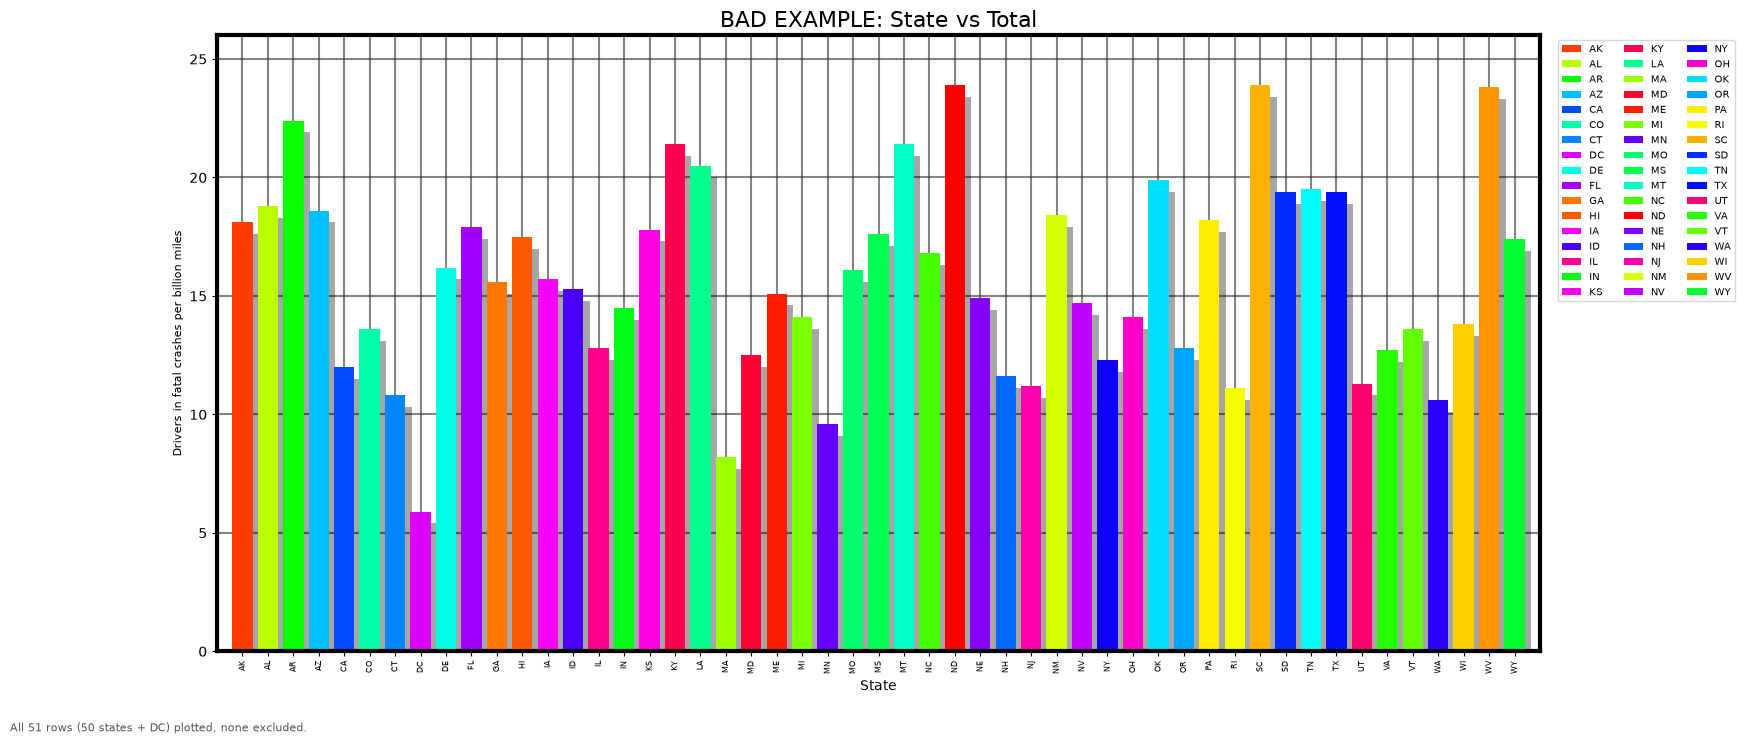

In [2]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_states(ax, cars, colours='rainbow', legend=True, frame=True, xgrid=True, ygrid='heavy', shadow=True, xlabels='all')
ax.set_title('BAD EXAMPLE: State vs Total', fontsize=16)
ax.set_xlabel('State')
fig.text(0.01, 0.01, 'All 51 rows (50 states + DC) plotted, none excluded.', fontsize=8, color='#555')
fig.subplots_adjust(right=0.86)
fig.savefig('t3_1_bad_example.png', dpi=130, bbox_inches='tight'); plt.show()
ink_bad = ink(ax)

## 2. Count the load

| Element | Count | Load type | Why |
|---|---|---|---|
| Bars (height = `total`) | 51 | **Intrinsic** | The data itself. |
| Y tick labels + y-axis label with units | 6 + 1 | **Intrinsic** | Without the scale and unit the bar heights mean nothing. |
| X tick labels (state names, rotated 90°) | 51 | **Intrinsic** (the names) + **Extraneous** (the rotation) | One copy of the names is needed; head-tilting 51 labels is pure cost. |
| 51 different bar colours | 51 | **Extraneous** | Duplicate what x position already says. |
| 51-entry legend (swatch + name) | 102 | **Extraneous** | Third copy of the state names; forces colour → key → bar matching. |
| Drop-shadow bars | 51 | **Extraneous** | Encode nothing. |
| Heavy vertical gridlines | 51 | **Extraneous** | A categorical axis has no values to read across to. |
| Heavy horizontal gridlines | 6 | **Extraneous as drawn** (a light version would be **germane**) | Help read values, but thick dark lines compete with the bars. |
| Box frame (4 spines, 3 pt) | 4 | **Extraneous** | Only left and bottom axis lines help. |
| Tick marks | 57 | **Extraneous** | Bars are already aligned to their labels. |
| X-axis label "State" | 1 | **Extraneous** | Redundant with the labels. |
| Title "State vs Total" | 1 | **Extraneous** | Names the axes; states no finding. |
| Anything germane (sort, highlight, direct label, reference) | 0 | none | The chart does nothing to help the reader build a schema. |

**Data-ink ratio (working shown).** A mark counts as data-ink if it encodes a number. Counts below come from the Axes object itself.

In [3]:
for k, v in ink_bad['parts'].items(): print(f'{k:28s}{v:5d}')
print('-' * 33)
print(f"{'TOTAL marks':28s}{ink_bad['total']:5d}")
print(f"\nStrict data-ink ratio  = {ink_bad['data']} / {ink_bad['total']} = {ink_bad['ratio']:.1%}")
gen = (ink_bad['data'] + 51) / ink_bad['total']
print(f"Generous (also keep ONE copy of the 51 state names as data-bearing) = {ink_bad['data']+51} / {ink_bad['total']} = {gen:.1%}")

data marks (bars/points)       51
drop-shadow bars               51
gridlines                      57
tick marks                     57
tick labels                    57
frame/axis lines                4
legend swatches+names         102
axis labels                     2
title                           1
annotations                     0
reference lines                 0
---------------------------------
TOTAL marks                   382

Strict data-ink ratio  = 51 / 382 = 13.4%
Generous (also keep ONE copy of the 51 state names as data-bearing) = 102 / 382 = 26.7%


So the strict ratio is **51 / 382 = 13%**: 87% of the ink is not carrying a number. Even if I generously treat one copy of the state names as data-bearing, it is 102 / 382 = 27%.

## 3. Strip it down, one step at a time
Order used: legend → frame/shadow/x-gridlines → one hue → sort → label only what matters. This follows the suggested order, with one addition: the **drop shadow goes with the frame in step 2**, because both are pure decoration with zero information.

Panels 1 and 2 still carry rainbow colouring, so they are marked `BAD EXAMPLE`; 3 and 4 are labelled as intermediate steps; panel 5 is the finished chart with a finding title.
**Pop-out in panel 5:** one strong colour (hue, used here as a categorical "this is the message" marker) on the three highest bars; everything else is grey. **Gestalt:** similarity (grey vs red) and proximity (label beside the bars).

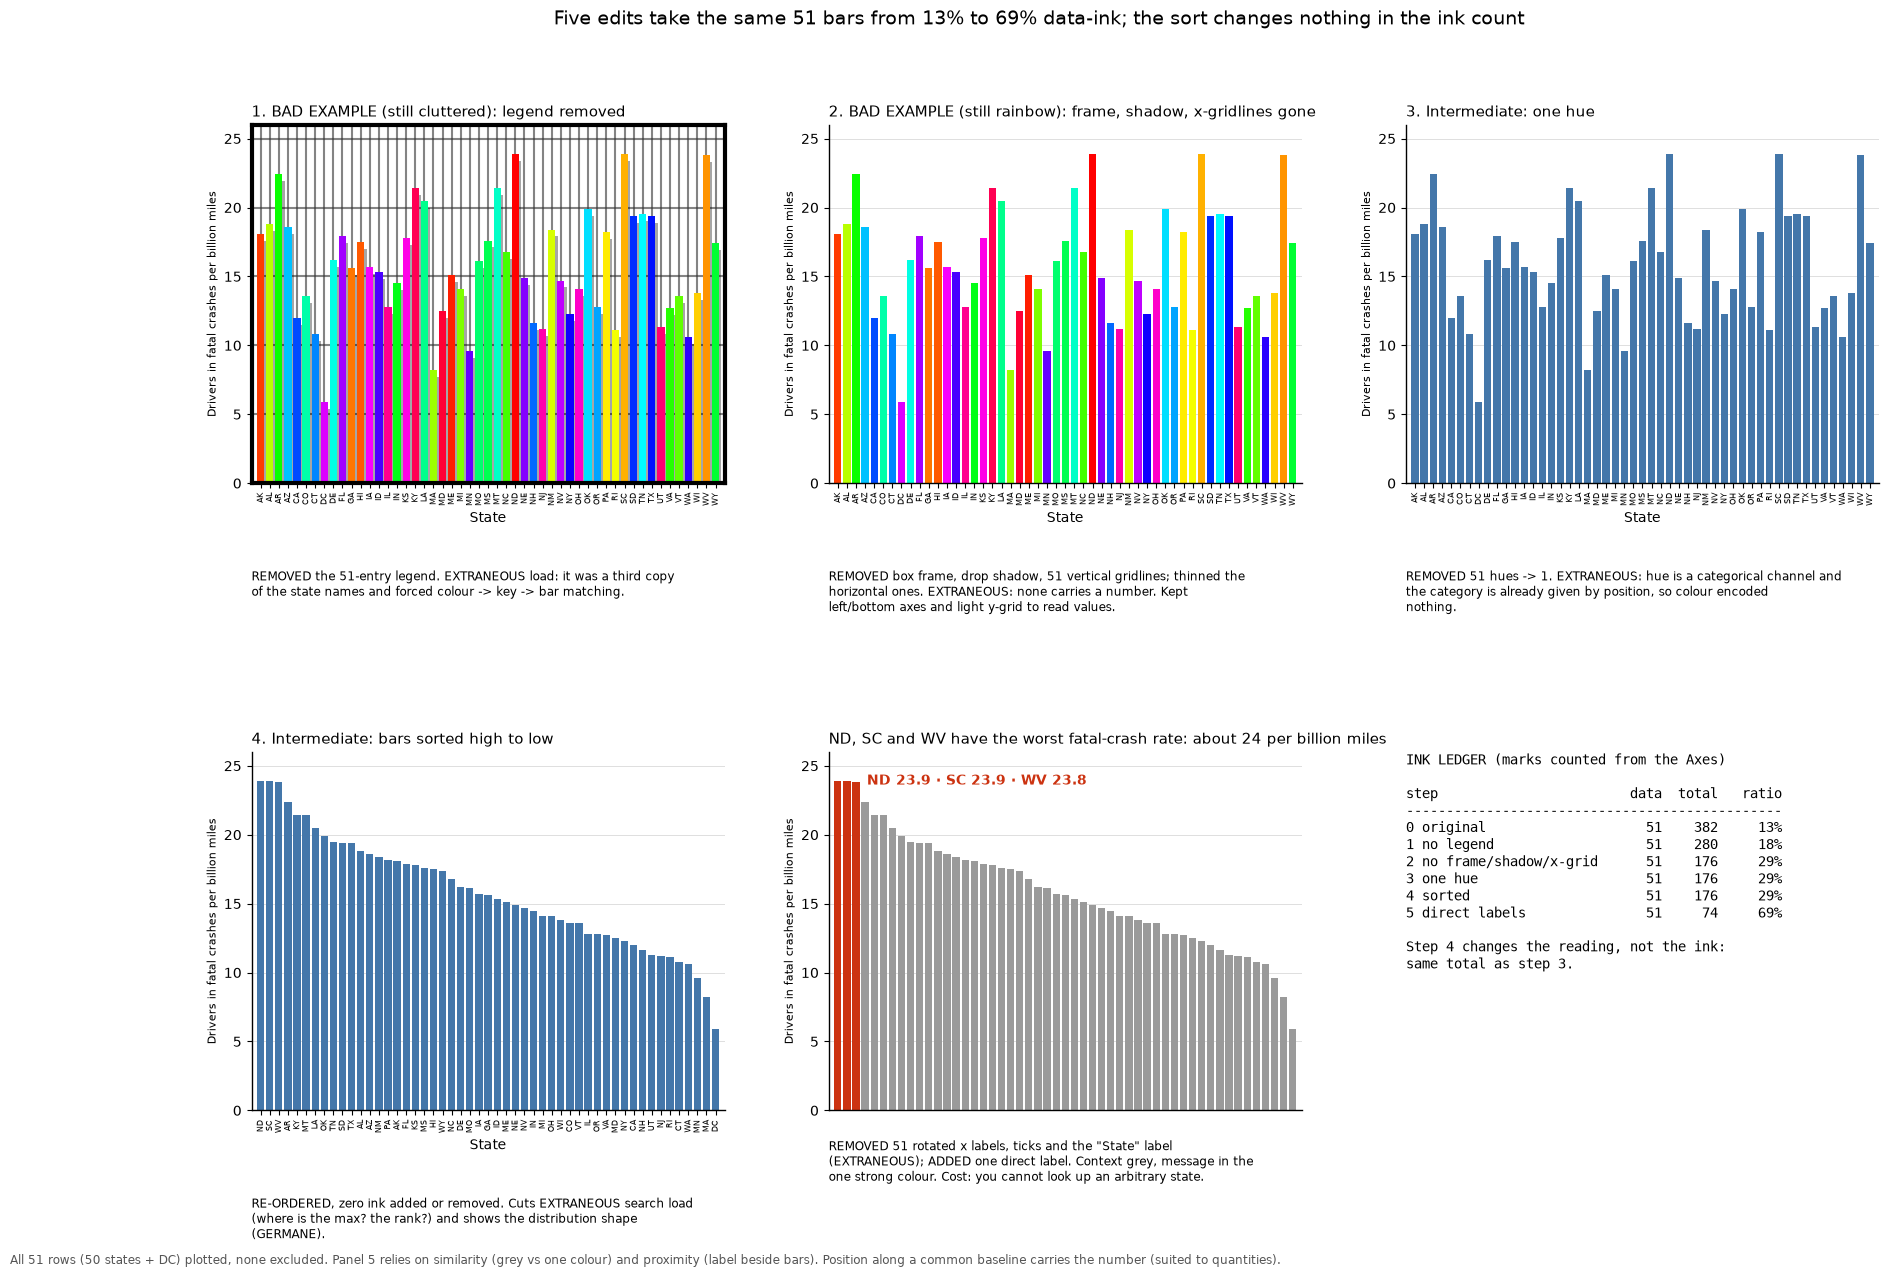

In [4]:
hi3 = list(cars.nlargest(3, 'total').abbrev)          # ND, SC, WV
steps = [
 ('1. BAD EXAMPLE (still cluttered): legend removed',
  dict(colours='rainbow', legend=False, frame=True, xgrid=True, ygrid='heavy', shadow=True, xlabels='all'),
  'REMOVED the 51-entry legend. EXTRANEOUS load: it was a third copy of the state names and forced colour -> key -> bar matching.'),
 ('2. BAD EXAMPLE (still rainbow): frame, shadow, x-gridlines gone',
  dict(colours='rainbow', legend=False, frame=False, xgrid=False, ygrid='light', shadow=False, xlabels='all'),
  'REMOVED box frame, drop shadow, 51 vertical gridlines; thinned the horizontal ones. EXTRANEOUS: none carries a number. Kept left/bottom axes and light y-grid to read values.'),
 ('3. Intermediate: one hue',
  dict(colours='blue', legend=False, frame=False, xgrid=False, ygrid='light', xlabels='all'),
  'REMOVED 51 hues -> 1. EXTRANEOUS: hue is a categorical channel and the category is already given by position, so colour encoded nothing.'),
 ('4. Intermediate: bars sorted high to low',
  dict(colours='blue', legend=False, frame=False, xgrid=False, ygrid='light', xlabels='all', sort=True),
  'RE-ORDERED, zero ink added or removed. Cuts EXTRANEOUS search load (where is the max? the rank?) and shows the distribution shape (GERMANE).'),
 (None,   # title written after the ledger is known
  dict(colours='hi', legend=False, frame=False, xgrid=False, ygrid='light', xlabels='none', sort=True, hi=hi3),
  'REMOVED 51 rotated x labels, ticks and the "State" label (EXTRANEOUS); ADDED one direct label. Context grey, message in the one strong colour. Cost: you cannot look up an arbitrary state.'),
]
fig = plt.figure(figsize=(21, 12.8))
gs = fig.add_gridspec(2, 3, hspace=0.75, wspace=0.22)
axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(5)]
ax6 = fig.add_subplot(gs[1, 2])
ledger = [('0 bad chart', ink_bad)]
for i, (ax, (ttl, kw, cap)) in enumerate(zip(axes, steps)):
    cont, s = plot_states(ax, cars, **kw)
    if i < 4: ax.set_xlabel('State')
    if i == 4:
        ax.text(3.2, 23.9, ' · '.join(f'{a} {v:.1f}' for a, v in zip(s.abbrev[:3], s.total[:3])),
                color=HI, fontsize=10, fontweight='bold', va='center')
    ax.text(0, -0.08 if i == 4 else -0.24, textwrap.fill(cap, 66), transform=ax.transAxes, va='top', fontsize=8.5)
    ledger.append((f'{i+1}', None, ax))
# titles need the ledger: compute ink first
res = [ink_bad] + [ink(ax) for ax in axes]
r0, r5 = res[0]['ratio'], res[5]['ratio']
for i, (ax, (ttl, kw, cap)) in enumerate(zip(axes, steps)):
    ax.set_title(ttl or f"{hi3[0]}, {hi3[1]} and {hi3[2]} have the worst fatal-crash rate: about 24 per billion miles", fontsize=10.5, loc='left')
labels = ['0 original', '1 no legend', '2 no frame/shadow/x-grid', '3 one hue', '4 sorted', '5 direct labels']
ax6.axis('off')
txt = 'INK LEDGER (marks counted from the Axes)\n\n' + f"{'step':26s}{'data':>6s}{'total':>7s}{'ratio':>8s}\n" + '-' * 47 + '\n'
for lab, r in zip(labels, res):
    txt += f"{lab:26s}{r['data']:6d}{r['total']:7d}{r['ratio']:8.0%}\n"
txt += '\nStep 4 changes the reading, not the ink:\nsame total as step 3.'
ax6.text(0, 1, txt, family='monospace', fontsize=10, va='top')
fig.suptitle(f'Five edits take the same 51 bars from {r0:.0%} to {r5:.0%} data-ink; the sort changes nothing in the ink count', fontsize=14, y=0.97)
fig.text(0.01, -0.01, 'All 51 rows (50 states + DC) plotted, none excluded. Panel 5 relies on similarity (grey vs one colour) and proximity (label beside bars). '
         'Position along a common baseline carries the number (suited to quantities).', fontsize=8.5, color='#555')
fig.savefig('t3_3_five_steps.png', dpi=130, bbox_inches='tight'); plt.show()

**Notice the sort.** Steps 3 and 4 have identical ink counts (176 marks, 51 of them data). Re-ordering the bars is the single highest-value edit and costs and removes nothing: the reader no longer scans 51 bars for the maximum, the minimum or a rank, and the shape of the distribution becomes visible.

## 4. Respect the 4 ± 1 limit
**Chunking chosen: four Census regions** (Northeast, Midwest, South, West; DC counted in the South). The reader holds 4 bars, not 51. Labels sit beside the bars (proximity) and the highest region is the one pop-out (similarity: one strong colour, rest grey). The x-axis is removed because every bar has a direct value label; the bars still start at zero.

I considered the alternative "top 5 + other 46 states", which also fits in working memory. Regions fit the question better because they give every state a home.

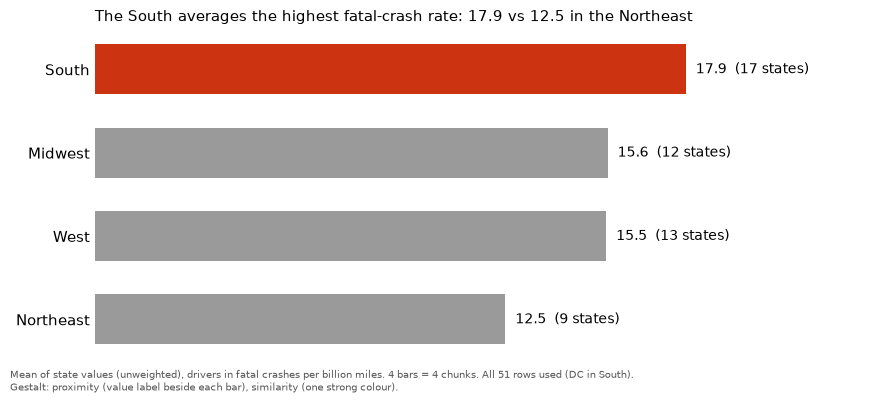

           mean   min   max  count  spread
region                                    
Northeast  12.5   8.2  18.2      9    10.0
West       15.5  10.6  21.4     13    10.8
Midwest    15.6   9.6  23.9     12    14.3
South      17.9   5.9  23.9     17    18.0

Three worst states and their regions: {'ND': 'Midwest', 'SC': 'South', 'WV': 'South'}
Gap between best and worst region MEAN: 5.5 | South within-region spread: 18.0


In [5]:
R = {'Northeast': 'CT ME MA NH RI VT NJ NY PA',
     'Midwest':   'IL IN MI OH WI IA KS MN MO NE ND SD',
     'South':     'DE FL GA MD NC SC VA DC WV AL KY MS TN AR LA OK TX',
     'West':      'AZ CO ID MT NV NM UT WY AK CA HI OR WA'}
reg = {a: r for r, v in R.items() for a in v.split()}
cars['region'] = cars.abbrev.map(reg); assert cars.region.notna().all()
g = cars.groupby('region').total.agg(['mean', 'min', 'max', 'count']).sort_values('mean')
fig, ax = plt.subplots(figsize=(9, 4))
top = g['mean'].idxmax()
ax.barh(g.index, g['mean'], height=0.6, color=[HI if r == top else GREY for r in g.index])
for y, (r, row) in enumerate(g.iterrows()):
    ax.text(row['mean'] + 0.3, y, f"{row['mean']:.1f}  ({int(row['count'])} states)", va='center', fontsize=10)
ax.set_xlim(0, 24)
for sp in ax.spines.values(): sp.set_visible(False)
ax.xaxis.set_visible(False); ax.tick_params(axis='y', length=0, labelsize=11)
ax.set_title(f"The South averages the highest fatal-crash rate: {g.loc['South','mean']:.1f} vs {g.loc['Northeast','mean']:.1f} in the Northeast", fontsize=11, loc='left')
fig.text(0.01, 0.01, 'Mean of state values (unweighted), drivers in fatal crashes per billion miles. 4 bars = 4 chunks. All 51 rows used (DC in South).\n'
         'Gestalt: proximity (value label beside each bar), similarity (one strong colour).', fontsize=7.5, color='#555', wrap=True)
fig.tight_layout(rect=[0, 0.05, 1, 1]); fig.savefig('t3_4_regions.png', dpi=130); plt.show()
g['spread'] = g['max'] - g['min']
print(g.round(1))
print('\nThree worst states and their regions:', {a: reg[a] for a in hi3})
print('Gap between best and worst region MEAN:', round(g['mean'].max() - g['mean'].min(), 1),
      '| South within-region spread:', round(g.loc['South', 'spread'], 1))

**What this chunking hides (every chunking hides something):**
- **Within-region spread.** The South's states run from 5.9 (DC) to 23.9 (SC), a spread of 18.0 points, while the whole gap between the best and worst region *means* is 5.5. Every region's range overlaps every other region's range.
- **Which states are bad.** The three worst states are ND (Midwest), SC and WV (South). The region chart cannot say a Midwest state is tied for worst; the Midwest bar looks middling.
- **Weighting.** The means are unweighted; Delaware counts the same as Texas. I had no population or mileage data to weight them.
- **A near-tie.** Midwest (15.6) and West (15.5) look identical, but Midwest contains a 23.9 state and the West's maximum is 21.4.

## 5. Over-strip it (BAD EXAMPLE)
Same sorted bars, but with no axis labels, no tick values, no units, no state names and no scale.

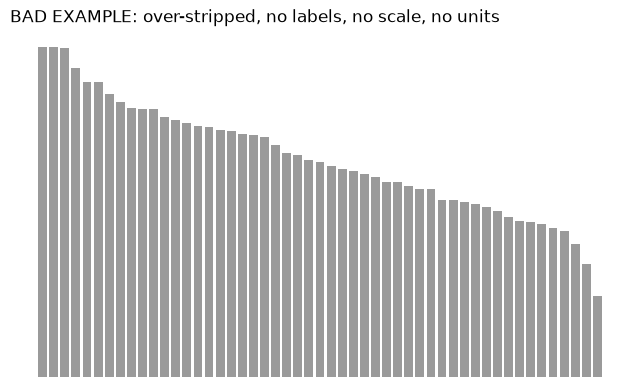

{'data marks (bars/points)': 51, 'drop-shadow bars': 0, 'gridlines': 0, 'tick marks': 0, 'tick labels': 0, 'frame/axis lines': 0, 'legend swatches+names': 0, 'axis labels': 0, 'title': 1, 'annotations': 0, 'reference lines': 0}
data-ink ratio = 51 / 52 = 98%


In [6]:
s = cars.sort_values('total', ascending=False, kind='stable')
fig, ax = plt.subplots(figsize=(8, 4.5))
for p in ax.bar(range(51), s.total, color=GREY, width=0.8): p.set_gid('data')
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_title('BAD EXAMPLE: over-stripped, no labels, no scale, no units', fontsize=12, loc='left')
fig.savefig('t3_5_over_stripped.png', dpi=130, bbox_inches='tight'); plt.show()
ink_over = ink(ax)
print(ink_over['parts']); print(f"data-ink ratio = {ink_over['data']} / {ink_over['total']} = {ink_over['ratio']:.0%}")

Its data-ink ratio is **51 / 52 = 98%**, higher than every good version above, and it communicates almost nothing. A reader cannot tell:
- what is measured, or its unit (crashes? dollars? percent?),
- what any bar's value is (no scale, no tick values),
- which bar is which state,
- whether higher is good or bad.

So the ratio is a **proxy** for extraneous load, not the goal. Maximising it blindly deletes the intrinsic and germane ink as well.

**Stopping rule for a colleague (one sentence):** keep deleting until the next deletion would make a first-time reader ask you a question (what unit, which one, how big, compared to what) that the chart currently answers on its own.

## The question: a chart where *adding* ink lowers cognitive load (tips.csv)
**Chart:** tip vs total bill, with a 15% reference line added on the right. **Attribute relied on:** position on two common scales (suited to two quantitative variables), plus hue on the *line only* as the one pop-out. **Gestalt:** continuity (the eye follows the line) and proximity (the label sits at the line). **Ink added:** one line and two text labels (the "15% of the bill" label and the "44% fall below" note).

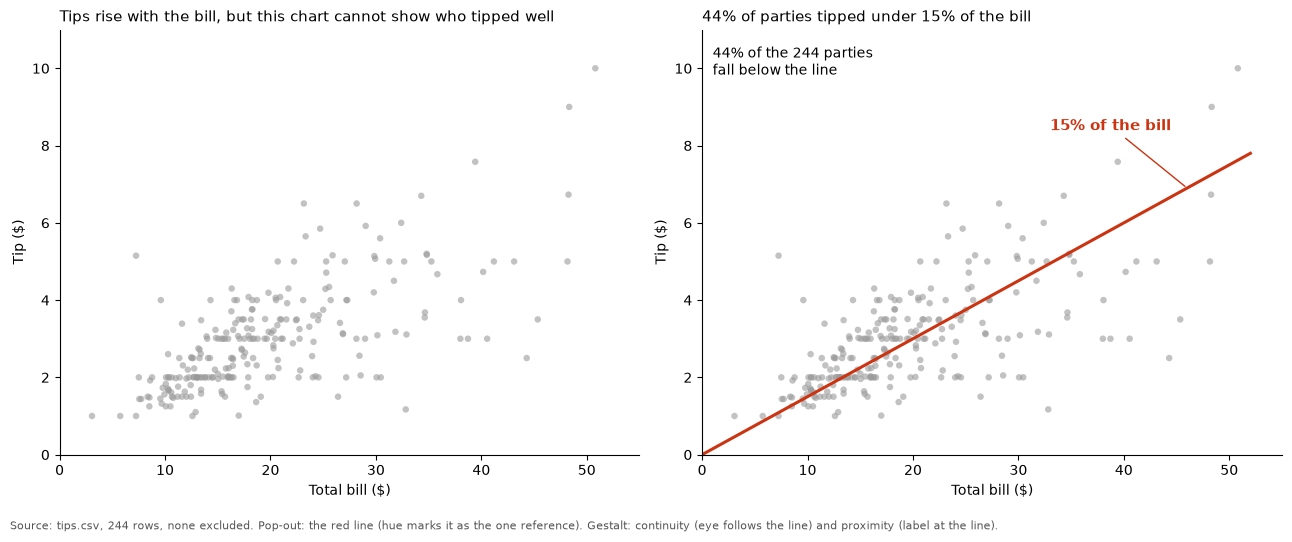

WITHOUT line: 244 / 273 = 89.4%
WITH line   : 244 / 276 = 88.4%   (added: 1 line + 2 text labels)


In [7]:
tips['rate'] = tips.tip / tips.total_bill
below = (tips.rate < 0.15).mean()
fig, axs = plt.subplots(1, 2, figsize=(13, 5.4), sharex=False, sharey=False)
for ax in axs:
    sc = ax.scatter(tips.total_bill, tips.tip, s=22, color=GREY, alpha=0.6, edgecolor='none'); sc.set_gid('data')
    ax.set_xlim(0, 55); ax.set_ylim(0, 11)
    ax.set_xlabel('Total bill ($)'); ax.set_ylabel('Tip ($)')
    for n in ('top', 'right'): ax.spines[n].set_visible(False)
axs[0].set_title('Tips rise with the bill, but this chart cannot show who tipped well', fontsize=11, loc='left')
xx = np.array([0, 52])
axs[1].plot(xx, 0.15 * xx, color=HI, lw=2.2)
axs[1].annotate('15% of the bill', xy=(46, 0.15 * 46), xytext=(33, 8.4), color=HI, fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=HI, lw=1))
axs[1].text(1, 10.6, f'{below:.0%} of the {len(tips)} parties\nfall below the line', fontsize=10, va='top')
axs[1].set_title(f'{below:.0%} of parties tipped under 15% of the bill', fontsize=11, loc='left')
fig.text(0.01, 0.01, f'Source: tips.csv, {len(tips)} rows, none excluded. Pop-out: the red line (hue marks it as the one reference). '
         'Gestalt: continuity (eye follows the line) and proximity (label at the line).', fontsize=8, color='#555')
fig.tight_layout(rect=[0, 0.04, 1, 1]); fig.savefig('t3_6_tips_reference_line.png', dpi=130); plt.show()
a, b = ink(axs[0]), ink(axs[1])
print(f"WITHOUT line: {a['data']} / {a['total']} = {a['ratio']:.1%}")
print(f"WITH line   : {b['data']} / {b['total']} = {b['ratio']:.1%}   (added: 1 line + 2 text labels)")

**Why the extra ink lowers load.** The question a reader actually has is "who tipped well?", which is a *ratio*, tip ÷ bill. In the left chart, answering it for even one point means estimating the point's slope from the origin in your head and comparing it with a remembered 15%. That is a calculation held in working memory, repeated for every point you care about (extraneous load created by *missing* ink). With the line, the same judgement becomes "is this dot above or below the line?", a position comparison that the visual system does without effort. The note "44% fall below the line" also saves counting. The data-ink ratio went *down* (89.4% → 88.4%), yet the reader does zero mental divisions instead of one per point.

**Why "maximise data-ink" is a heuristic, not a rule.** The ratio counts marks, but cognitive load depends on what the *reader has to compute*, not on how many marks there are:
1. The reference line encodes no row of the data, so a purist counts it as non-data ink, yet it encodes a derived quantity (the 15% rate) and removes work. It converts extraneous load into a cheap perceptual judgement, which makes it germane ink.
2. The over-stripped chart scores 98% and is useless, so a high ratio does not mean a good chart.
3. The ratio depends on how marks are counted (is a gridline one mark or one per tick?), so it is a rough guide, not a measurement.

The usable rule is: remove ink that adds reader work and keep ink that removes it.